# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [1]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/retailmax.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

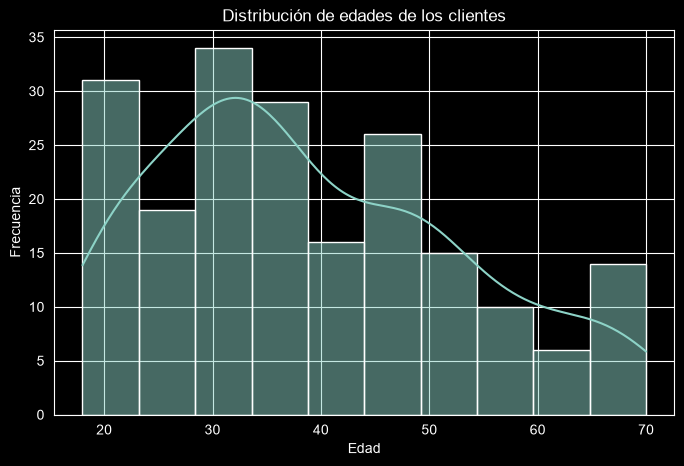

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True)

plt.title('Distribución de edades de los clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

La mayoría de los clientes se encuentran entre los 30 y 50 años aproximadamente. La distribución muestra que RetailMax cuenta con clientes de diferentes edades, aunque hay una mayor concentración en adultos jóvenes y adultos de mediana edad.

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

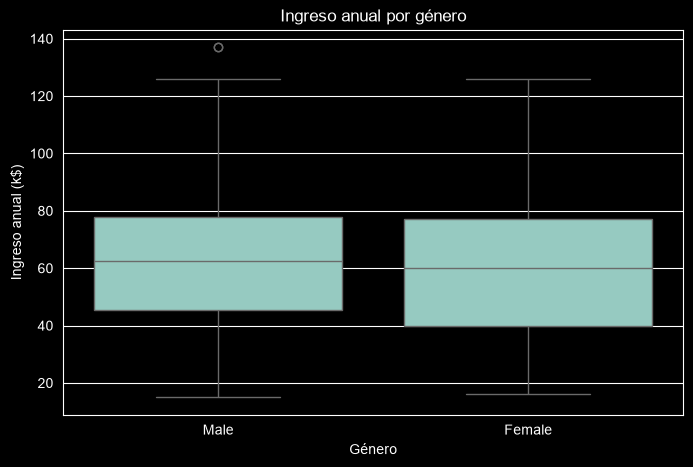

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Gender', y='Annual Income (k$)')

plt.title('Ingreso anual por género')
plt.xlabel('Género')
plt.ylabel('Ingreso anual (k$)')

plt.show()

Los ingresos anuales entre hombres y mujeres son bastante similares. No se observa una diferencia muy marcada entre ambos grupos, aunque pueden existir pequeñas variaciones en la mediana y en la dispersión de los datos.

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

In [8]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 55, 70],
    labels=['18-25', '26-35', '36-45', '46-55', '56-70']
)

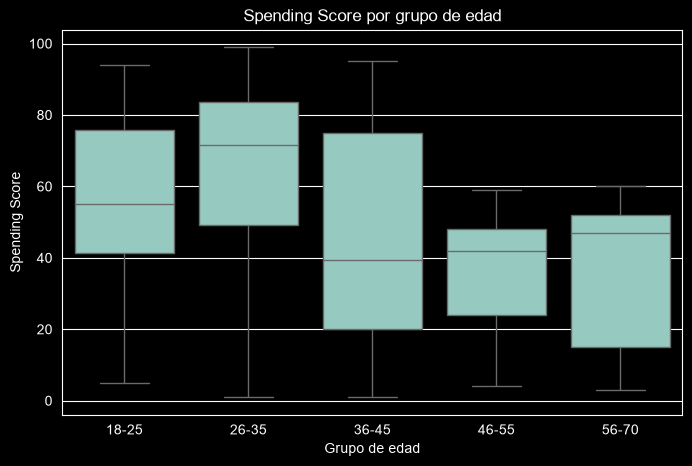

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Age Group', y='Spending Score (1-100)')

plt.title('Spending Score por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Spending Score')

plt.show()

Los clientes más jóvenes tienden a tener puntuaciones de gasto más altas. Esto indica que los grupos de menor edad podrían ser más activos en compras o responder mejor a estrategias de marketing.

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

In [10]:
correlacion = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])
correlacion

np.float64(0.009902848094037608)

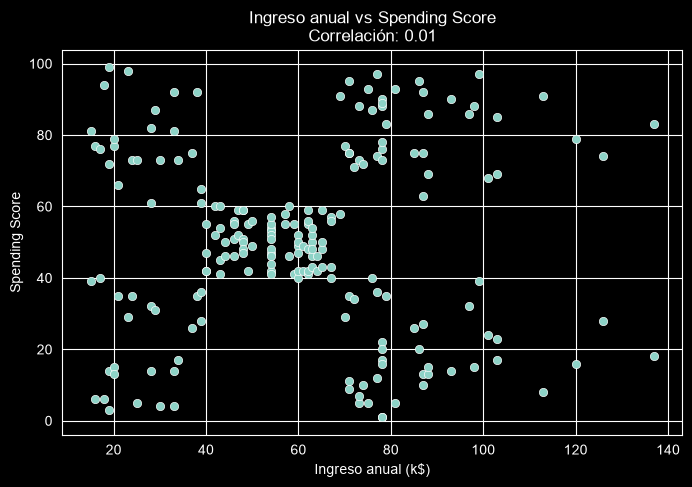

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

plt.title(f'Ingreso anual vs Spending Score\nCorrelación: {correlacion:.2f}')
plt.xlabel('Ingreso anual (k$)')
plt.ylabel('Spending Score')

plt.show()

La correlación entre el ingreso anual y el Spending Score es muy baja, por lo que no existe una relación lineal fuerte entre ambas variables. Esto significa que tener mayor ingreso no necesariamente implica gastar más.

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

In [12]:
df['Income Group'] = pd.cut(
    df['Annual Income (k$)'],
    bins=[0, 40, 70, 100, 150],
    labels=['Bajo', 'Medio', 'Alto', 'Muy alto']
)

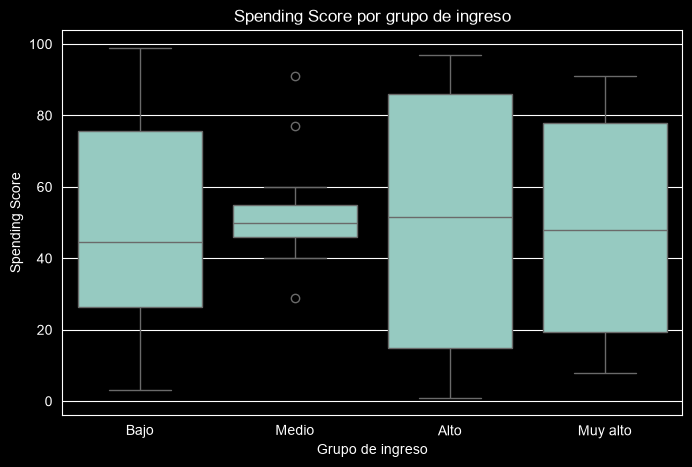

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Income Group', y='Spending Score (1-100)')

plt.title('Spending Score por grupo de ingreso')
plt.xlabel('Grupo de ingreso')
plt.ylabel('Spending Score')

plt.show()

La puntuación de gasto varía dentro de todos los grupos de ingreso. Esto muestra que no todos los clientes con ingresos altos tienen un alto nivel de gasto, y que también existen clientes con ingresos medios o bajos que pueden gastar considerablemente.

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

In [14]:
conteo_genero = df['Gender'].value_counts()
conteo_genero

Gender
Female    112
Male       88
Name: count, dtype: int64

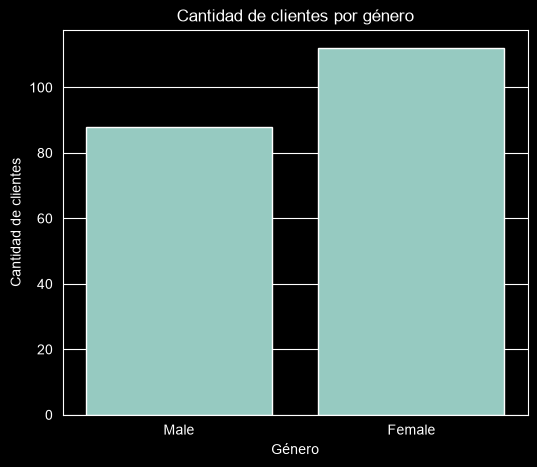

In [15]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Gender')

plt.title('Cantidad de clientes por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')

plt.show()

El conjunto de datos tiene más clientes mujeres que hombres. Esto permite observar que la base de clientes de RetailMax está ligeramente inclinada hacia el género femenino.


### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

In [17]:
gasto_promedio_edad = df.groupby('Age Group')['Spending Score (1-100)'].mean()
gasto_promedio_edad

Age Group
18-25    54.352941
26-35    64.450000
36-45    44.833333
46-55    36.702703
56-70    38.379310
Name: Spending Score (1-100), dtype: float64

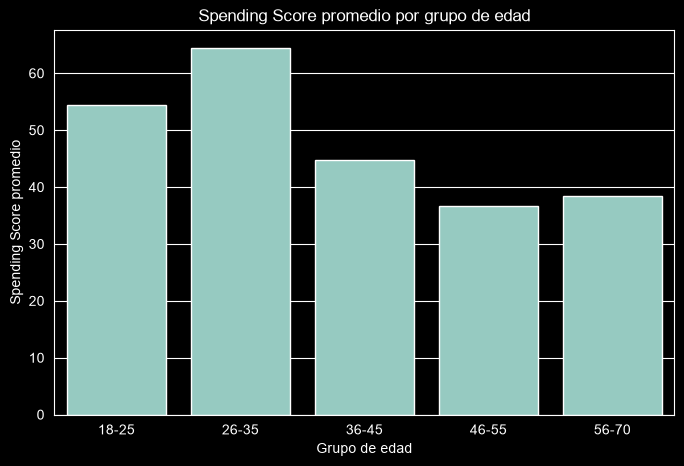

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=gasto_promedio_edad.index,
    y=gasto_promedio_edad.values
)

plt.title('Spending Score promedio por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Spending Score promedio')

plt.show()

Los grupos de edad más jóvenes presentan un Spending Score promedio más alto. Esto sugiere que RetailMax podría enfocar campañas más dinámicas o promocionales hacia estos segmentos.

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

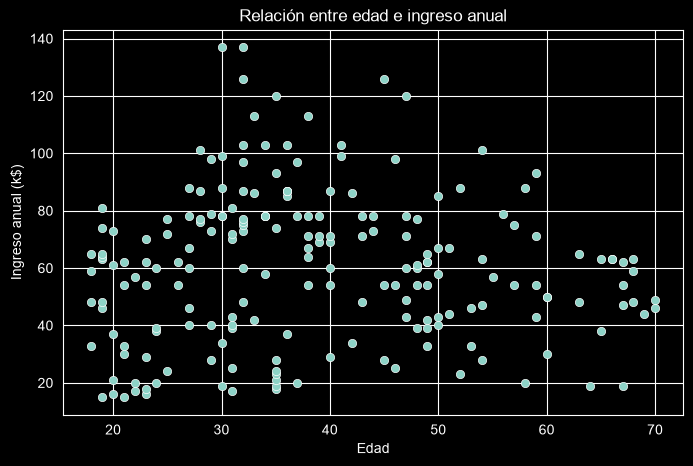

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Age',
    y='Annual Income (k$)'
)

plt.title('Relación entre edad e ingreso anual')
plt.xlabel('Edad')
plt.ylabel('Ingreso anual (k$)')

plt.show()

No se observa una relación clara entre la edad y el ingreso anual. Los clientes de distintas edades pueden tener ingresos bajos, medios o altos, por lo que la edad por sí sola no explica el nivel de ingreso.

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

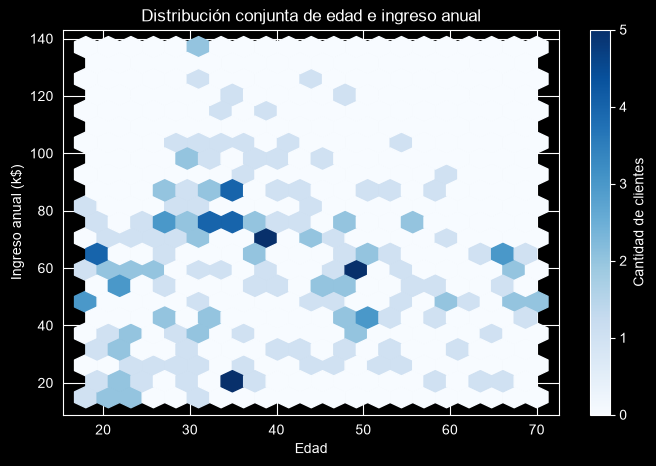

In [20]:
plt.figure(figsize=(8,5))
plt.hexbin(
    df['Age'],
    df['Annual Income (k$)'],
    gridsize=20,
    cmap='Blues'
)

plt.colorbar(label='Cantidad de clientes')
plt.title('Distribución conjunta de edad e ingreso anual')
plt.xlabel('Edad')
plt.ylabel('Ingreso anual (k$)')

plt.show()

La distribución conjunta muestra cómo se concentran los clientes según edad e ingreso. Se puede observar que existen clientes de distintas edades en varios niveles de ingreso, sin una concentración única muy marcada.

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

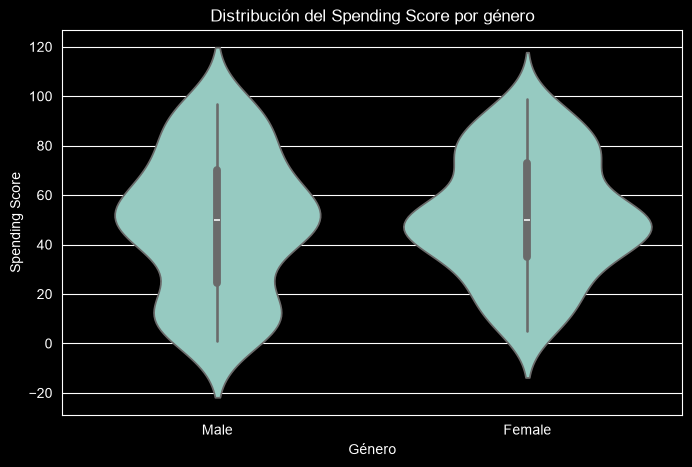

In [21]:
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x='Gender',
    y='Spending Score (1-100)'
)

plt.title('Distribución del Spending Score por género')
plt.xlabel('Género')
plt.ylabel('Spending Score')

plt.show()

La distribución del Spending Score es amplia tanto en hombres como en mujeres. Ambos géneros tienen clientes con puntuaciones bajas, medias y altas, por lo que el género por sí solo no determina completamente el comportamiento de gasto.